# Experimento 05 · Tus dos distribuciones de pesos, A y B

**Pregunta:** ¿redistribuir las contribuciones de los bits 4 y 5 reduce los cambios de decisión de la red que escapan a los detectores del notebook 09?

Comparamos tus dos propuestas con una base binaria. Se conserva la resolución de 1 ppb, el campo de valor de 16 bits y el payload de cuatro bytes. **El dominio experimental es 0–255 ppb**, como en los experimentos 02 y 04; falta acordar el rango de un formato definitivo.

Usa el kernel `Python (lorawan11 .venv)`. Hay una única celda ejecutable, explicada paso a paso debajo. Reutiliza predicciones y p95 de los **27 modelos guardados del notebook 09**: no entrena, no recalibra y no calcula predicciones nuevas. Los originales limpios se recuperan exactamente; su tasa de falsas alarmas permanece igual.

El cálculo está en `selectiva_red.py`. Los productos de esta ejecución se guardan únicamente en `resultados/05/`. Se pueden regenerar con las mismas fuentes; si cambia el protocolo o el código, se detiene antes de sobrescribir una referencia distinta.

## 1. Dibujar las dos propuestas

- **A:** bit 4 original, `16 → 8 + 8`; bit 5 original, `32 → 16 + 16`.
- **B:** bit 4 original, `16 → 8 + 8`; bit 5 original, `32 → 8 + 8 + 8 + 8`. El bit 3 conserva 8: todos los fragmentos de las contribuciones originales 8, 16 y 32 tienen el mismo peso.

| Posición física | Base binaria | A | B |
|---:|---:|---:|---:|
| 0, 1, 2 | 1, 2, 4 | 1, 2, 4 | 1, 2, 4 |
| 3 | 8 | 8 | 8 |
| 4 | 16 | 8 | 8 |
| 5 | 32 | 16 | 8 |
| 6 | 64 | 64 | 64 |
| 7 | 128 | 128 | 128 |
| 8 | Reservado | 8 (fragmento de 16) | 8 (fragmento de 16) |
| 9 | Reservado | 16 (fragmento de 32) | 8 (fragmento de 32) |
| 10, 11 | Reservados | Reservados | 8, 8 (fragmentos de 32) |
| 12–15 | Reservados | Reservados | Reservados |

A ocupa 10 posiciones activas y B ocupa 12. Emisor y receptor deben compartir esa regla. Los bits 6 y 7 se conservan y actúan como referencias.

**Codificar:** si una contribución original estaba encendida, encendemos todos sus fragmentos; si estaba apagada, apagamos todos. **Decodificar:** sumamos los pesos de las posiciones encendidas, aun si los fragmentos difieren. No se incorpora una alarma por discordancia ni corrección de errores. Cualquier bit reservado encendido provoca rechazo.

Ejemplo: `160 = 128 + 32`. En A es `128 + 16 + 16`; en B es `128 + 8 + 8 + 8 + 8`. Un flip de un fragmento de 32 original produce 144 en A y 152 en B; ambos siguen pudiendo bajar de 155. Reducir el delta no garantiza conservar una decisión cercana al umbral.

El canal 1 y tipo 02 se conservan como convención del laboratorio. A/B cambian la interpretación del campo; no son compatibles con un decodificador CayenneLPP genérico.

## 2. Una comparación justa

El caso **base** reproduce el binario original en los bits 0–7 y añade un filtro de dominio que rechaza los bits 8–15. Así las tres variantes comparten el rango 0–255; no atribuimos a la redistribución una mejora que provenga únicamente de rechazar valores inválidos. En 0–7 se comprueba que la base reproduce los resultados guardados del notebook 09.

Cada escenario ataca **un mensaje actual y una posición física**, manteniendo intactas las otras lecturas. Se incluyen **las 16 posiciones**, también las nuevas y las reservadas, con los mismos mensajes para cada formato. No se evalúan todavía dos flips, secuencias de ataques ni propagación a perfiles futuros o a las entradas de otros detectores.

El atacante conoce el formato, pero no el contenido del mensaje. Un flip puede sumar o restar según el estado previo. El barrido no elige para cada mensaje la dirección más favorable.

Se valida la tabla completa de 256 valores × 16 bits × 3 formatos contra la cadena de cifrado, inversión y descifrado del FRMPayload del repositorio. Después se usa esa tabla para evaluar los mensajes: el resultado decodificado de ese flip depende del valor y del formato. Esto no es una prueba de extremo a extremo con radios, MIC y retransmisiones.

**Rechazo ≠ corrección:** se cuenta aparte como lectura perdida. No se atribuye al LSTM ni se interpreta como ausencia de impacto operativo. En este experimento no se modela qué hace la aplicación ante ese mensaje faltante.

## 3. Qué medimos y sobre qué datos

**Test con LSTM:** mismos 35 704 mensajes y 72 días del notebook 09 (21/oct–31/dic/2025). Cada mensaje usa la predicción de su estación y su p95 guardado. Se aplica la misma aritmética numérica del experimento de referencia y se recalcula el máximo diario conservando todas las demás estaciones y horas.

- **Cambio de banda del máximo diario:** objetivo principal que motivó seleccionar los bits 4–5.
- **Falsa excedencia de 155:** objetivo separado; no se mezcla con cambios de banda.
- **Ocultamiento:** se reporta, pero el test tiene máximo original 152 ppb. Su ausencia de casos no demuestra protección.

Contamos directamente daño y ausencia de alerta **en el mismo escenario**. No usamos el producto de oportunidad diaria y no detección global.

**Año completo sin LSTM:** 218 823 lecturas, 365 días y seis días con máximo ≥155. Evaluamos cambios del máximo diario y ocultamientos manteniendo las lecturas competidoras. No extrapolamos los detectores del test a este año completo.

Tres lecturas complementarias del resultado:

1. **Promedio uniforme:** escenarios con daño no detectado / (mensajes × 16). Corresponde a elegir uniformemente una lectura observada y una posición física. No presupone que un atacante real lo haga.
2. **Peor bit fijo:** posición que maximiza ese conteo en 2025; la misma posición para todos los mensajes. Es una selección retrospectiva, no una garantía para otro año.
3. **Unión de días:** días con al menos una oportunidad bajo alguna posición. No se suman los días de distintos bits y no se interpreta como probabilidad de éxito de un atacante ciego.

La tabla pareada compara exactamente la misma lectura y posición: oportunidades previas que desaparecen, las que persisten y las nuevas que aparecen. Las nuevas posiciones activas también entran en ese balance.

## 4. Ejecutar

La celda verifica las fuentes y checkpoints por hash, comprueba la transformación cifrada, ejecuta el cálculo **dos veces** y exige tablas idénticas antes de guardar resultados. Las pruebas adicionales están en `test_selectiva_red.py`.

Antes de ejecutar: ¿crees que B será mejor al considerar **todos** sus fragmentos, o solo si miramos la posición física 5?

Validando los 256 valores y los flips a través del cifrado del repositorio…
12,288 escenarios de cifrado verificados.


Primera evaluación terminada. Comprobando repetibilidad…


Tablas idénticas en dos ejecuciones. Predicciones de modelos GUARDADOS; sin entrenamiento.
Test: 35,704 mensajes, 72 días; FP limpios: 15.80% (se conservan).


### Cambio de banda del máximo diario: daño que escapa al LSTM

,formato,n_escenarios,daninos,daninos_no_detectados,pct_escape_uniforme,dias_escape_union,peor_bit_fijo,escapes_peor_bit_fijo,pct_rechazos
0,base,571264,35417,408,0.07142,22,5.0,228,50.0
3,A,571264,34649,219,0.03834,20,6.0,106,37.5
6,B,571264,34505,185,0.03238,15,6.0,106,25.0


...

### Balance pareado: eliminados y nuevos respecto a la base

,escapan_base,persisten,eliminados,nuevos,escapan_candidata
formato,,,,,
base,408,408,0,0,408
A,408,152,256,67,219
B,408,133,275,52,185


### Año completo: daño SIN evaluación LSTM

,formato,tipo_dano,daninos,dias_vulnerables_union,pct_rechazos
0,base,cambio_banda_red,213822,365,50.0
1,base,falsa_fase1,101329,358,50.0
2,base,anulada_fase1,8,3,50.0
3,A,cambio_banda_red,210598,365,37.5
4,A,falsa_fase1,100984,358,37.5
5,A,anulada_fase1,11,3,37.5
6,B,cambio_banda_red,209950,365,25.0
7,B,falsa_fase1,100816,358,25.0
8,B,anulada_fase1,7,3,25.0


Ocultamiento en test: sin casos originales ≥155 (máximo 152).
Ocultamiento anual: interpretar sobre 6 días con excedencia, además de los 365 días totales.


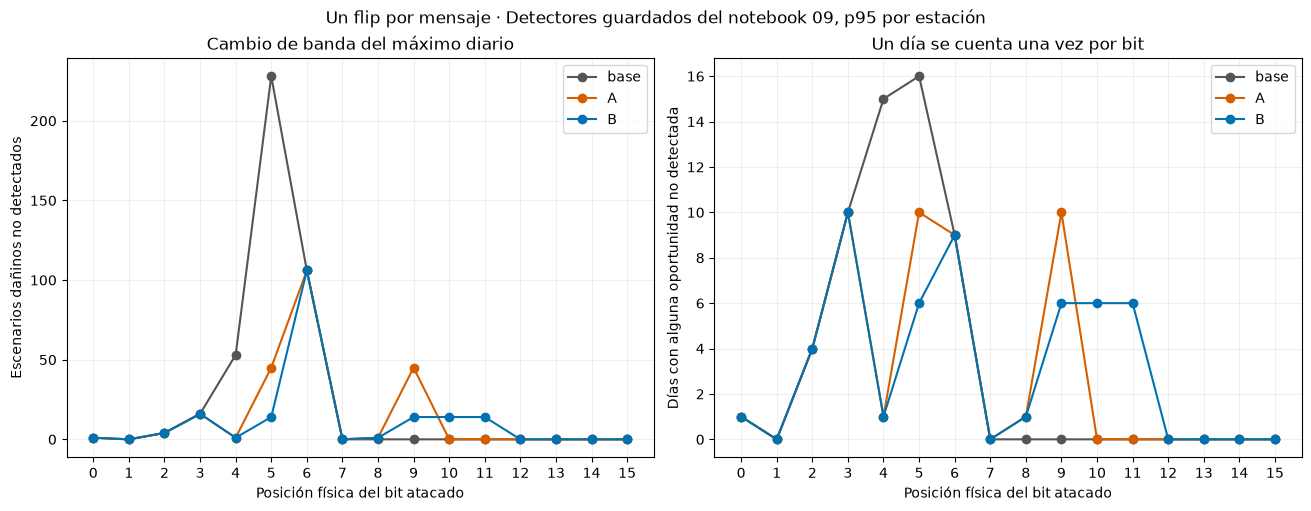

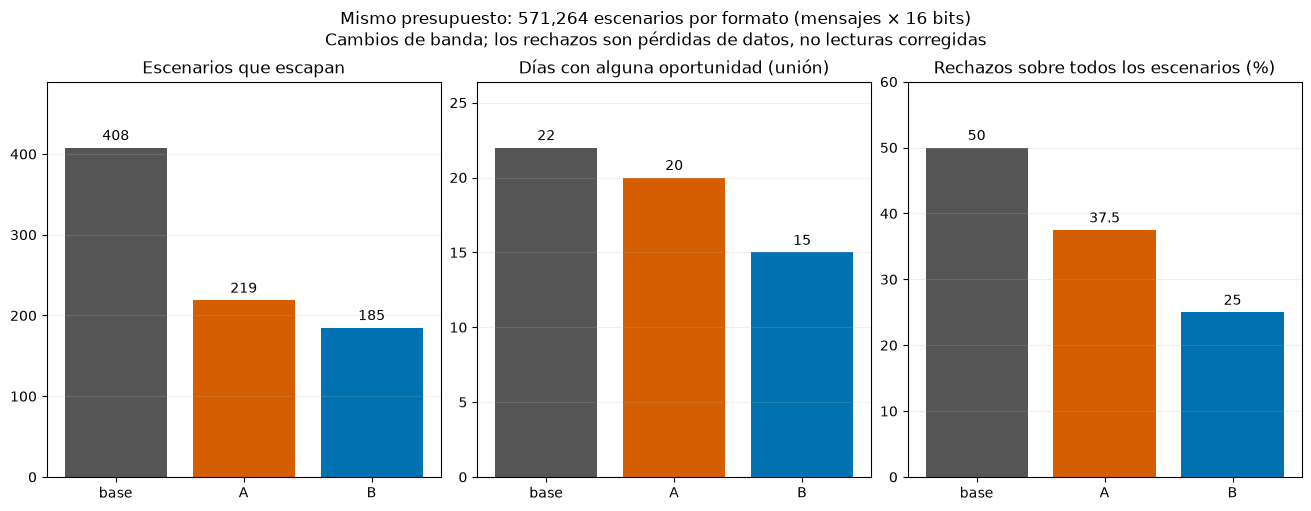

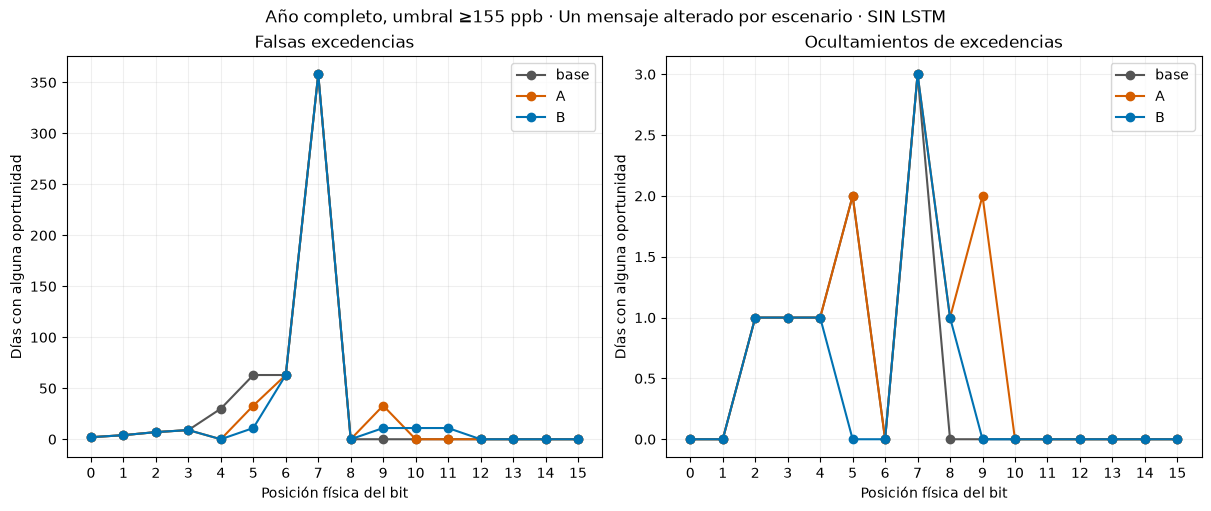

Productos: experiments/cayenne_mod/resultados/05


In [1]:
from pathlib import Path
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

actual = Path.cwd().resolve()
RAIZ = next(p for p in (actual, *actual.parents)
            if (p / "experiments/cayenne_mod/selectiva_red.py").is_file())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from experiments.cayenne_mod import selectiva_red
selectiva_red = importlib.reload(selectiva_red)

print("Validando los 256 valores y los flips a través del cifrado del repositorio…")
n_cifrado = selectiva_red.validar_cifrado()
print(f"{n_cifrado:,} escenarios de cifrado verificados.")
test, anual, info = selectiva_red.construir(RAIZ)
print("Primera evaluación terminada. Comprobando repetibilidad…")
test2, anual2, info2 = selectiva_red.construir(RAIZ)
assert info == info2
for primero, segundo in [(test, test2), (anual, anual2)]:
    for nombre in primero:
        pd.testing.assert_frame_equal(primero[nombre], segundo[nombre], check_exact=True)
del test2, anual2
info["escenarios_cifrado_verificados"] = n_cifrado
info["reproducibilidad"] = "Dos cálculos completos con tablas exactamente iguales"
DESTINO = selectiva_red.guardar(RAIZ, test, anual, info)
print("Tablas idénticas en dos ejecuciones. Predicciones de modelos GUARDADOS; sin entrenamiento.")
print(f"Test: {info['test_mensajes']:,} mensajes, {info['test_dias']} días; "
      f"FP limpios: {info['fpr_limpio_pct']:.2f}% (se conservan).")

for tipo, titulo in [("cambio_banda_red", "Cambio de banda del máximo diario"),
                     ("falsa_fase1", "Falsas excedencias del máximo diario ≥155")]:
    display(Markdown(f"### {titulo}: daño que escapa al LSTM"))
    g = test["resumen"].query("tipo_dano == @tipo")
    display(g[["formato", "n_escenarios", "daninos", "daninos_no_detectados",
               "pct_escape_uniforme", "dias_escape_union", "peor_bit_fijo",
               "escapes_peor_bit_fijo", "pct_rechazos"]].round(5))

display(Markdown("### Cambio de banda: resultado por posición física"))
t = test["por_bit"].query("tipo_dano == 'cambio_banda_red'")
display(t.pivot(index="bit", columns="formato", values="daninos_no_detectados").reindex(columns=["base", "A", "B"]))
display(Markdown("### Balance pareado: eliminados y nuevos respecto a la base"))
p = test["pareados"].query("tipo_dano == 'cambio_banda_red'")
display(p.groupby("formato", sort=False)[["escapan_base", "persisten", "eliminados", "nuevos", "escapan_candidata"]].sum())
display(Markdown("### Año completo: daño SIN evaluación LSTM"))
display(anual["resumen"][["formato", "tipo_dano", "daninos", "dias_vulnerables_union", "pct_rechazos"]])
print(f"Ocultamiento en test: sin casos originales ≥155 (máximo {info['test_maximo_ppb']:g}).")
print(f"Ocultamiento anual: interpretar sobre {info['anual_dias_excedencia']} días con excedencia, "
      "además de los 365 días totales.")
selectiva_red.graficar(test, anual, DESTINO)
plt.show()
print(f"Productos: {DESTINO.relative_to(RAIZ)}")

## Lectura de la ejecución del 30/sep/2026

Las dos ejecuciones dieron tablas exactamente iguales. Se verificaron 12 288 transformaciones a través del cifrado. Los resultados corresponden a predicciones persistidas de los modelos del notebook 09 y sus p95; no se entrenaron modelos.

**Con el mismo presupuesto de 571 264 escenarios por formato, ambas propuestas redujeron los cambios de banda que escapan al detector.**

| Formato | Escenarios dañinos no detectados | Reducción frente a base | Días con alguna oportunidad (unión) |
|---|---:|---:|---:|
| Base con control de rango | 408 | — | 22/72 |
| A | 219 | 46.32 % | 20/72 |
| B | 185 | 54.66 % | 15/72 |

Los escenarios son contrafactuales, no ataques ocurridos. La reducción del conteo equivale a la reducción del éxito medio bajo selección uniforme de mensaje y posición, porque el denominador es el mismo. No demuestra una reducción universal ante cualquier estrategia del atacante.

### ¿La mejora depende de ignorar los bits nuevos?

No: la siguiente tabla cuenta **todos los fragmentos** de cada contribución original. No supone que el atacante invierta varios a la vez.

| Contribución original | Base | A: suma de escenarios por fragmento | B: suma de escenarios por fragmento |
|---|---:|---:|---:|
| 16 ppb (bit 4 original) | 53 | 1 + 1 = **2** | 1 + 1 = **2** |
| 32 ppb (bit 5 original) | 228 | 45 + 45 = **90** | 14 + 14 + 14 + 14 = **56** |
| Otras posiciones | 127 | 127 | 127 |

Cada término cuenta mensajes cuyo ataque en esa posición cambia la banda del máximo diario y no genera alerta. Los fragmentos de un mismo grupo dan cifras idénticas porque comparten su estado inicial; los bits de igual peso pertenecientes a grupos distintos no tienen por qué dar la misma cifra.

El balance pareado confirma que no todo escenario mejora: A elimina 256 oportunidades previas y crea 67 nuevas; B elimina 275 y crea 52. Al contar todo, sus resultados netos son 219 y 185.

**El peor bit fijo pasa del 5 (228 escenarios) al 6 (106 escenarios)** en ambas candidatas. Por esta métrica A y B empatan: la ventaja adicional de B aparece en el conteo agregado y en la unión de días. El bit 6 no cambió; otros riesgos se hicieron menores.

### No mezclar los tipos de daño

Para **falsas excedencias de 155 que escapan al LSTM**, la base tiene un escenario, A tiene dos y B ninguno. Base y A afectan a un solo día; dos posiciones distintas pueden ofrecer una oportunidad sobre la misma lectura. Cero en B describe este test y no garantiza protección general.

Para **ocultamientos anuales, SIN LSTM**, el número de escenarios pasa de 8 en la base a 11 en A y 7 en B. En los tres formatos sigue habiendo alguna oportunidad en los mismos tres días de los seis que tenían excedencias. El test con LSTM carece de originales ≥155 y no permite evaluar su detección.

Los rechazos son 50 %, 37.5 % y 25 % para base, A y B cuando se consideran por igual las 16 posiciones. La menor tasa en las candidatas se debe a que más posiciones están activas; no significa por sí sola mejor seguridad. Su efecto como datos perdidos queda pendiente.

**B es la candidata con mejor resultado agregado en este experimento exploratorio; no es todavía una contramedida validada fuera de estos datos.** Las falsas alarmas limpias siguen en 15.80 %.

Esta interpretación corresponde al protocolo de `resultados/05/protocolo.json`; revisarla si se crea una nueva referencia con otros datos o diseños.

## 5. Interpretación y límites

Para elegir entre A y B hay que leer juntos los conteos totales, el peor bit fijo y la unión de días. La mejora de una posición original no basta: revisa también las nuevas posiciones 8–11. Los cambios en los bits 6 y 7 deberían ser nulos porque conservan sus pesos y su estado; si no lo fueran, habría que revisar la implementación.

Los rechazos conservan su propio conteo. Si desaparece un cruce porque se perdió el mensaje, eso no demuestra que la decisión de la aplicación sea correcta ante la ausencia. Los escenarios dañinos se guardan en `test_eventos_daninos.csv.gz`, con lectura, predicción, umbral, formato y bit para poder inspeccionarlos.

Estos datos ya motivaron la selección de 4 y 5: **el experimento es exploratorio**, no una validación independiente. Antes de afirmar generalización habrá que fijar el diseño y probar otro periodo/año. Tampoco se ha elegido aquí un rango definitivo de ozono ni evaluado energía, latencia, ataques persistentes o varias inversiones simultáneas.

Las falsas alarmas limpias siguen en 15.80 %: cambiar la codificación exacta no arregla por sí mismo ese problema del detector. “Detectado” significa que la lectura atacada genera alerta; no necesariamente que una lectura antes normal pase a generar una alerta nueva.

## Tus observaciones

- ¿La mejora de los bits 4 y 5 se conserva al contar también 8–11?
- ¿A y B cambian el peor bit que podría elegir el atacante?
- ¿Disminuyen tanto el número de escenarios que escapan como los días con alguna oportunidad?
- ¿Qué ocurre con el ocultamiento en el análisis anual, sin atribuirle detección LSTM?

Escribe aquí tus notas y la candidata que propondrías discutir con el asesor.